![Ironhack logo](https://user-images.githubusercontent.com/23629340/40541063-a07a0a8a-601a-11e8-91b5-2f13e4e6b441.png)

# 01 | Exploratory Data Analysis

*Project 1 — SQL: From Data to Insight*

**Student:** Gabriel Gomes

**Dataset:** Inside Airbnb (Rio de Janeiro)

---

# Introduction

## Questions

## Dataset Description

The data is the latest of the periodic snapshots of every Airbnb listing in Rio de Janeiro, taken on June 24th, 2026, and published by [Inside Airbnb](https://insideairbnb.com/).

Since Rio is my hometown, I located the corresponding data page (`https://data.insideairbnb.com/brazil/rj/rio-de-janeiro/2026-06-24/`) and adapted the `download_data.py` script to fetch the datasets from it.

While browsing the site, I found additional datasets that broaden the scope of the project. The files used throughout the project are listed below:

| File | Rows | Columns | Description |
|---|---|---|---|
| `listings.csv.gz` | 48,713 | 90 | One row per listing. Columns include price, room type, neighborhood, host, review scores, and availability. |
| `reviews.csv.gz` | 1,388,472 | 6 | One row per review. Columns include `listing_id`, `date`, `reviewer_id`, `reviewer_name`, and `comments`. |
| `neighbourhoods.csv` | 160 | 2 | One row per neighborhood. Columns include the neighborhood name. |
| `neighbourhoods.geojson` | 160 | 3 | One row per neighborhood. Columns include the neighborhood name and its geometry. |




# Setup

## Importing libraries

In [1]:
import sys
sys.path.append("..")          

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import geopandas as gpd

%load_ext autoreload
%autoreload 2
from src.functions import *

pd.set_option("display.max_columns", 100)
sns.set_theme(style="whitegrid")

In [46]:
# Set the Seaborn context to "poster" for larger text and figures
sns.set_context("poster")

# Set the default figure size for Seaborn plots
sns.set(rc={"figure.figsize": (12., 6.)})

# Set the Seaborn style to "whitegrid" for a white background with gridlines
sns.set_style("whitegrid")

# 1.  First Look

To conduct the exploratory data analysis, we first need to load the raw datasets into pandas DataFrames. Besides the data provided by Inside Airbnb, I also needed a table mapping each neighborhood (*bairro*, in Portuguese) in Rio to its corresponding planning area, which will be used later on.

Since I could not find a ready-made CSV online, I used Claude to convert the [PDF published by the Rio city government](https://www.rio.rj.gov.br/dlstatic/10112/5148142/4145881/ListadeBairroseAPs_Mapa) into a CSV table, which I then saved in my raw data directory.

In [11]:
listings_raw = pd.read_csv("../data/raw/listings.csv.gz")
reviews_raw = pd.read_csv("../data/raw/reviews.csv.gz")
neighborhoods_raw = pd.read_csv("../data/raw/neighbourhoods.csv")
neighborhoods_geo_raw = gpd.read_file("../data/raw/neighbourhoods.geojson")
bairros = pd.read_csv("../data/raw/bairros.csv")

## DataFrames Info

Next, let's examine the structure of each DataFrame: its columns, the data type of each column, and the number of non-null values.


In [5]:
listings_raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 48713 entries, 0 to 48712
Data columns (total 90 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   id                                            48713 non-null  int64  
 1   listing_url                                   48713 non-null  str    
 2   scrape_id                                     48713 non-null  int64  
 3   last_scraped                                  48713 non-null  str    
 4   source                                        48713 non-null  str    
 5   name                                          48713 non-null  str    
 6   description                                   47704 non-null  str    
 7   neighborhood_overview                         0 non-null      float64
 8   picture_url                                   48713 non-null  str    
 9   host_id                                       48713 non-null  int64  
 1

In [6]:
reviews_raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 1388472 entries, 0 to 1388471
Data columns (total 6 columns):
 #   Column         Non-Null Count    Dtype
---  ------         --------------    -----
 0   listing_id     1388472 non-null  int64
 1   id             1388472 non-null  int64
 2   date           1388472 non-null  str  
 3   reviewer_id    1388472 non-null  int64
 4   reviewer_name  1388468 non-null  str  
 5   comments       1388435 non-null  str  
dtypes: int64(3), str(3)
memory usage: 386.6 MB


In [10]:
neighborhoods_raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 160 entries, 0 to 159
Data columns (total 2 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   neighbourhood_group  0 non-null      float64
 1   neighbourhood        160 non-null    str    
dtypes: float64(1), str(1)
memory usage: 4.3 KB


In [12]:
neighborhoods_geo_raw.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 160 entries, 0 to 159
Data columns (total 3 columns):
 #   Column               Non-Null Count  Dtype   
---  ------               --------------  -----   
 0   neighbourhood        160 non-null    str     
 1   neighbourhood_group  0 non-null      object  
 2   geometry             160 non-null    geometry
dtypes: geometry(1), object(1), str(1)
memory usage: 5.6+ KB


## Samples

Next, let's get a feel for the data by looking at 10 random rows from each DataFrame, to understand what kind of information each column holds.


In [8]:
listings_raw.sample(10)

,id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,host_url,host_profile_id,host_profile_url,host_name,host_since,hosts_time_as_user_years,hosts_time_as_user_months,hosts_time_as_host_years,hosts_time_as_host_months,host_location,host_about,host_response_time,host_response_rate,host_acceptance_rate,host_is_superhost,host_thumbnail_url,host_picture_url,host_neighbourhood,host_listings_count,host_total_listings_count,host_verifications,host_has_profile_pic,host_identity_verified,neighbourhood,neighbourhood_cleansed,neighbourhood_group_cleansed,latitude,longitude,property_type,room_type,accommodates,bathrooms,bathrooms_text,bedrooms,beds,amenities,price,price_quote_checkin_date,price_quote_checkout_date,price_quote_total_price,price_quote_price_per_night,price_quote_raw,minimum_nights,maximum_nights,minimum_minimum_nights,maximum_minimum_nights,minimum_maximum_nights,maximum_maximum_nights,minimum_nights_avg_ntm,maximum_nights_avg_ntm,calendar_updated,has_availability,availability_30,availability_60,availability_90,availability_365,calendar_last_scraped,number_of_reviews,number_of_reviews_ltm,number_of_reviews_l30d,availability_eoy,number_of_reviews_ly,estimated_occupancy_l365d,estimated_revenue_l365d,first_review,last_review,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
35809,13697963,https://www.airbnb.com/rooms/13697963,20260624212719,2026-06-25,city scrape,Beautiful House In The Botanical Gardens.,"Beautiful house in the Botanical Gardens, mode...",NaN,https://a0.muscache.com/pictures/28f3e98d-af48...,32860022,https://www.airbnb.com/users/show/32860022,1.465481e+18,https://www.airbnb.com/users/profile/146548148...,Fernando,NaN,11.0,1.0,11.0,1.0,"Rio de Janeiro, Brazil",Sou um mineiro radicado no Rio de Janeiro e qu...,NaN,NaN,NaN,f,NaN,https://a0.muscache.com/im/pictures/user/e6514...,NaN,1.0,NaN,NaN,t,t,NaN,Jardim Botânico,NaN,-22.965270,-43.237590,Entire home,Entire home/apt,12,7.0,7 baths,5.0,12.0,"[""Hot tub"", ""Carbon monoxide alarm"", ""TV"", ""El...","$5,890.00",2026-06-25,2026-06-30,29450.00,5890.00,"{""quote"": {""taxes"": null, ""currency"": ""USD"", ""...",5.0,15.0,5.0,5.0,15.0,15.0,5.0,15.0,NaN,t,30,60,90,365,2026-06-25,0,0,0,190,0,0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,1,0,0,NaN
15922,688205399623784791,https://www.airbnb.com/rooms/688205399623784791,20260624212719,2026-06-26,city scrape,Mini ap no Coração de Copacabana! 5 min da praia,Mini apartment with the best location for thos...,NaN,https://a0.muscache.com/pictures/hosting/Hosti...,50442621,https://www.airbnb.com/users/show/50442621,1.462716e+18,https://www.airbnb.com/users/profile/146271641...,Flávia Corina,NaN,10.0,6.0,10.0,6.0,"Rio de Janeiro, Brazil",NaN,NaN,NaN,NaN,t,NaN,https://a0.muscache.com/im/pictures/user/User/...,NaN,8.0,NaN,NaN,t,t,NaN,Copacabana,NaN,-22.970645,-43.187883,Entire rental unit,Entire home/apt,4,1.0,1 bath,NaN,3.0,"[""Multilaser - Uma boca el\u00e9trico electric...",$237.25,2026-07-02,2026-07-06,949.01,237.25,"{""quote"": {""taxes"": null, ""currency"": ""USD"", ""...",3.0,28.0,3.0,6.0,28.0,28.0,3.2,28.0,NaN,t,9,38,68,75,2026-06-26,142,46,3,75,45,255,60499.0,2022-09-05,2026-06-20,4.94,4.96,4.98,4.97,4.99,4.96,4.90,NaN,NaN,7,7,0,0,3.06
27122,1573233090226573698,https://www.airbnb.com/rooms/1573233090226573698,20260624212719,2026-07-01,previous scrape,Apartamento no Coração do Flamengo,🏡 Apartment in the Heart of Flamengo — History...,NaN,https://a0.muscache.com/pictures/hosting/Hosti...,2398632,https://www.airbnb.com/users/show/2398632,1.573233e+18,https://www.airbnb.com/users/profile/157323309...,Bruna,NaN,14.0,1.0,0.0,6.0,"São Paulo, Brazil",Brun

In [9]:
reviews_raw.sample(10)

,listing_id,id,date,reviewer_id,reviewer_name,comments
156521,7578378,132199406,2017-02-16,77944627,Anna,"Apartamento muito confortável, decoração bela,..."
917879,975297603123653365,1571868451362504062,2025-12-08,339191094,Valeria,"Todo estuvo muy bien. Departamento muy lindo, ..."
496153,42170325,1257323645483464609,2024-09-30,266641126,Regina,Minha experiência foi ótima! Maria foi muito a...
667555,519496968451958499,719578146633298156,2022-09-19,474735135,Debora,Nina é maravilhosa e muito atenciosa a casa da...
1046317,1116687226507925303,1144981749333338348,2024-04-28,112322830,Hector,El mejor Airbnb en el que me que quedado súper...
1229300,1357399222869460268,1566836530231444739,2025-12-01,372327638,Nathalia,Recomendo de olhos fechados. Apartamento impec...
909857,964007323086812696,1002881452743979505,2023-10-15,272887910,Henrique,"Lugar confortável e limpo, em localizaçao cent..."
489166,40989017,863789179529246092,2023-04-06,214331075,Len,I stayed here for eight nights. <br/>All commu...
1232704,1360381262795028330,1420338013355957841,2025-05-13,3201870,Cirlea,O espaço da Mönica é fantástico! Super confort...
1188435,1312409420690914975,1468990239345036954,2025-07-19,6164835,Eduardo,"Apartamento muito bem localizado, a poucos qua..."


In [14]:
neighborhoods_raw.sample(10)

,neighbourhood_group,neighbourhood
92,NaN,Maria da Graça
1,NaN,Acari
156,NaN,Vila Militar
5,NaN,Andaraí
104,NaN,Pechincha
26,NaN,Catumbi
158,NaN,Vista Alegre
45,NaN,Engenheiro Leal
110,NaN,Pitangueiras
49,NaN,Estácio


In [15]:
neighborhoods_geo_raw.sample(10)

,neighbourhood,neighbourhood_group,geometry
62,Santa Cruz,None,"MULTIPOLYGON Z (((-43.67852 -22.86396 0, -43.6..."
73,Pilares,None,"MULTIPOLYGON Z (((-43.29453 -22.87286 0, -43.2..."
19,Praia da Bandeira,None,"MULTIPOLYGON Z (((-43.17744 -22.80792 0, -43.1..."
77,Piedade,None,"MULTIPOLYGON Z (((-43.30881 -22.8753 0, -43.30..."
97,Jacaré,None,"MULTIPOLYGON Z (((-43.24909 -22.8901 0, -43.24..."
126,Vargem Grande,None,"MULTIPOLYGON Z (((-43.44281 -22.94526 0, -43.4..."
116,Santa Teresa,None,"MULTIPOLYGON Z (((-43.17717 -22.91787 0, -43.1..."
59,Tomás Coelho,None,"MULTIPOLYGON Z (((-43.29806 -22.85905 0, -43.2..."
58,Inhaúma,None,"MULTIPOLYGON Z (((-43.28584 -22.85758 0, -43.2..."
66,Cavalcanti,None,"MULTIPOLYGON Z (((-43.30881 -22.8753 0, -43.30..."


To see what the `geometry` column actually stores, let's plot the GeoJSON neighborhoods DataFrame. The result is a map in which each neighborhood appears as a delimited area, side by side with its neighbors.

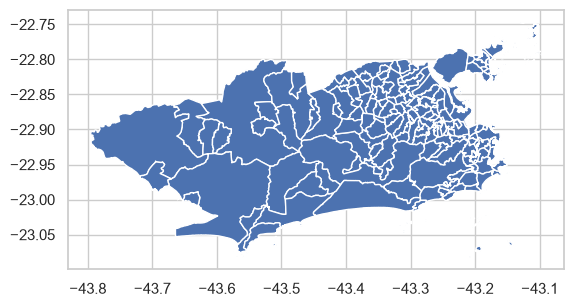

In [18]:
neighborhoods_geo_raw.plot()
plt.show()

# 2. Data Quality

The next goal is to spot missing values, duplicates, and data type inconsistencies, such as numbers stored as text or dates stored as strings. The `get_quality` function is our main tool at this stage: it produces a table that quantifies the problems in each DataFrame's columns.

The quality table for the `listings` DataFrame below shows that several columns contain only null values. These will be dropped later, at the data cleaning stage.

Inspecting the data type of each column also reveals inconsistencies in the same DataFrame. They include strings that should be booleans (`host_is_superhost`), strings that should be floats (`price`), and integers that should be floats (`minimum_nights`). These conversions are noted here and will be carried out only if the columns prove relevant to the research questions.

In [37]:
get_quality(listings_raw)

Rows: 48713  |  Columns: 90  |  Duplicated rows: 0


,dtype,nulls,nulls_%,blanks,n_unique
host_response_rate,float64,48713,100.0,0,0
host_neighbourhood,float64,48713,100.0,0,0
host_thumbnail_url,float64,48713,100.0,0,0
host_total_listings_count,float64,48713,100.0,0,0
host_acceptance_rate,float64,48713,100.0,0,0
neighborhood_overview,float64,48713,100.0,0,0
host_response_time,float64,48713,100.0,0,0
host_verifications,float64,48713,100.0,0,0
calendar_updated,float64,48713,100.0,0,0
neighbourhood,float64,48713,100.0,0,0


Repeating the process for the other DataFrames shows that `reviews` is in good shape, with only a few null values across the entire table and consistent data types. In the `neighbourhoods` DataFrame, however, `neighbourhood_group` contains only null values. This column will be filled in later, at the data cleaning stage.

In [22]:
get_quality(reviews_raw)

Rows: 1388472  |  Columns: 6  |  Duplicated rows: 0


,dtype,nulls,nulls_%,blanks,n_unique
reviewer_name,str,4,0.0,0,139492
comments,str,37,0.0,0,1322493


In [21]:
get_quality(neighborhoods_raw)

Rows: 160  |  Columns: 2  |  Duplicated rows: 0


,dtype,nulls,nulls_%,blanks,n_unique
neighbourhood_group,float64,160,100.0,0,0


# 3. Distributions

In the preliminary list of numeric columns below, three groups look promising for the analysis. The first is the listing's price per night (`price_quote_price_per_night`), the second is the number of guests each listing accommodates (`accommodates`), and the third is the seven review scores (`review_scores_*`) that guests give after a stay. Let's explore their distributions.

In [39]:
listings_raw.select_dtypes(include="number").columns

Index(['id', 'scrape_id', 'neighborhood_overview', 'host_id',
       'host_profile_id', 'host_since', 'hosts_time_as_user_years',
       'hosts_time_as_user_months', 'hosts_time_as_host_years',
       'hosts_time_as_host_months', 'host_response_time', 'host_response_rate',
       'host_acceptance_rate', 'host_thumbnail_url', 'host_neighbourhood',
       'host_listings_count', 'host_total_listings_count',
       'host_verifications', 'neighbourhood', 'neighbourhood_group_cleansed',
       'latitude', 'longitude', 'accommodates', 'bathrooms', 'bedrooms',
       'beds', 'price_quote_total_price', 'price_quote_price_per_night',
       'minimum_nights', 'maximum_nights', 'minimum_minimum_nights',
       'maximum_minimum_nights', 'minimum_maximum_nights',
       'maximum_maximum_nights', 'minimum_nights_avg_ntm',
       'maximum_nights_avg_ntm', 'calendar_updated', 'availability_30',
       'availability_60', 'availability_90', 'availability_365',
       'number_of_reviews', 'number_of_revie

A brief overview of these columns, obtained with the `describe` method, already offers some insights:

- The price per night has a maximum value of $574,000. A price this extreme suggests some kind of error and these values will be examined during cleaning. 
- The median price per night of $452.67 is roughly half the mean of $877.71, which indicates a right-skewed distribution driven by a few very expensive listings.
- The maximum guest capacity is 16.
- As expected, the review scores range from 0 to 5, and their averages are high, at around 4.8.

In [ ]:
numeric_colums = ['price_quote_price_per_night','accommodates','review_scores_rating', 'review_scores_accuracy', 'review_scores_cleanliness',
       'review_scores_checkin', 'review_scores_communication', 'review_scores_location', 'review_scores_value']

listings_raw[numeric_colums].describe()

,price_quote_price_per_night,accommodates,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value
count,44542.000000,48713.000000,38890.000000,38889.000000,38890.000000,38890.000000,38889.000000,38889.000000,38888.000000
mean,877.707421,3.929177,4.805776,4.822588,4.782412,4.888010,4.880676,4.855876,4.733233
std,4599.612177,2.261917,0.379010,0.363851,0.396330,0.305366,0.320955,0.312643,0.412239
min,5.540000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
25%,296.710000,2.000000,4.770000,4.800000,4.730000,4.890000,4.880000,4.830000,4.670000
50%,452.670000,4.000000,4.920000,4.930000,4.900000,4.980000,4.980000,4.950000,4.830000
75%,761.537500,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000
max,574013.000000,16.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000


In [65]:
listings_raw['price_quote_price_per_night'].median()

np.float64(452.67)

A quick calculation also shows that roughly 25% of the listing prices are outliers.

In [78]:
quantile_1 = listings_raw['price_quote_price_per_night'].quantile(0.25)
quantile_3 = listings_raw['price_quote_price_per_night'].quantile(0.75)

iqr = quantile_3 - quantile_1

outlier_condition = listings_raw['price_quote_price_per_night'] > 1.5*iqr

num_outliers = listings_raw['price_quote_price_per_night'][outlier_condition].count()

outlier_fraction = num_outliers/len(listings_raw)
outlier_fraction

np.float64(0.2568102970459631)

The box plot below shows a significant number of outliers, while the bulk of the price per night distribution is hard to see because it is compressed against the left side of the plot.

[Text(0.5, 1.0, 'Distribution of Prices per Night'),
 Text(0.5, 0, 'Price per Night ($)')]

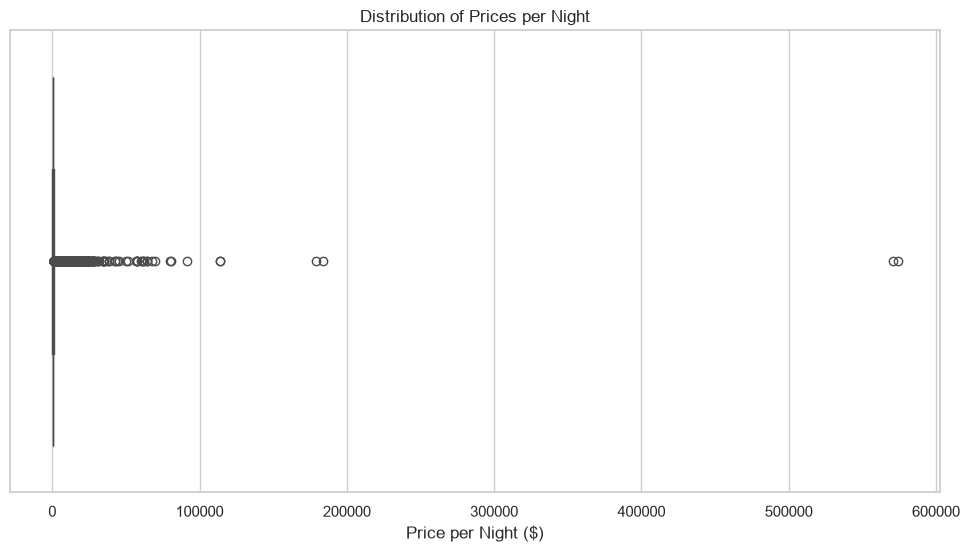

In [45]:
ax = sns.boxplot(data=listings_raw, x='price_quote_price_per_night')
ax.set(
    title="Distribution of Prices per Night",
    xlabel="Price per Night ($)"
)

To address this, we can restrict the price range to get a clearer view of the distribution. Instead of a box plot, let's use a violin plot, which also shows the kernel density estimate. From this plot, we get a better picture of the interquartile range.

[Text(0.5, 1.0, 'Distribution of Prices per Night'),
 Text(0.5, 0, 'Price per Night ($)'),
 (0.0, 10000.0)]

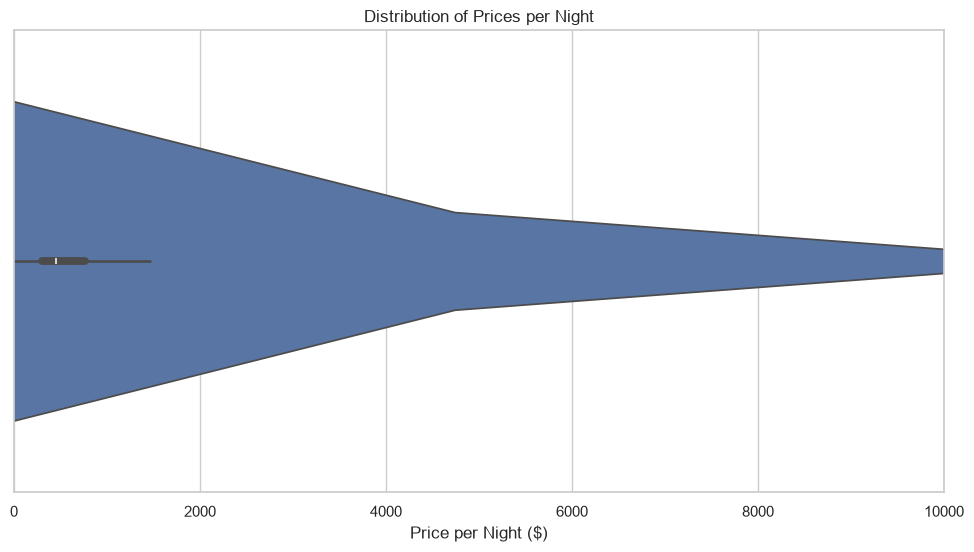

In [66]:
ax = sns.violinplot(data=listings_raw, x='price_quote_price_per_night')
ax.set(
    title="Distribution of Prices per Night",
    xlabel="Price per Night ($)",
    xlim=(0, 10000)
)

[Text(0.5, 1.0, 'Distribution of Guest Capacities'),
 Text(0.5, 0, 'Maximum Guest Capacity')]

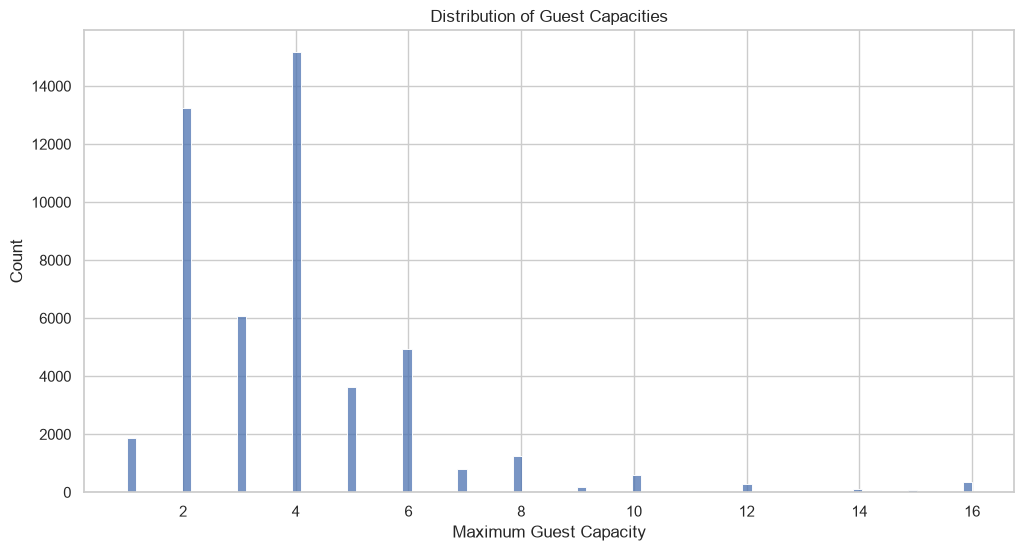

In [80]:
ax = sns.histplot(data=listings_raw, x='accommodates')
ax.set(
    title="Distribution of Guest Capacities",
    xlabel="Maximum Guest Capacity"
)

[Text(0.5, 1.0, 'Distribution of Review Rating Scores'),
 Text(0.5, 0, 'Review Rating Scores')]

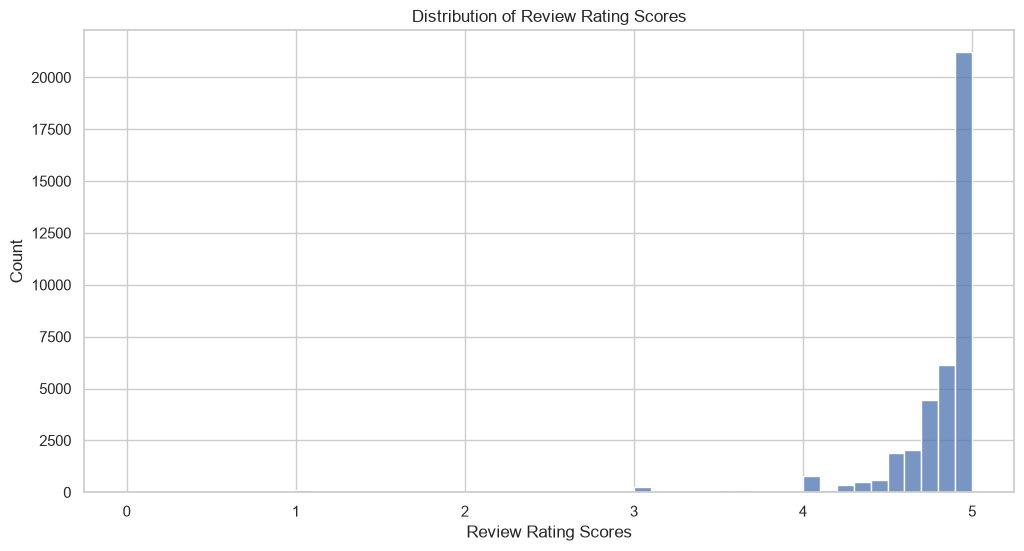

In [ ]:
ax = sns.histplot(data=listings_raw, x='review_scores_rating', bins=50)

ax.set(
    title="Distribution of Review Rating Scores",
    xlabel="Review Rating Scores"
)

# 4. Categorical Columns

In [91]:
categorical_columns = listings_raw.select_dtypes(exclude="number").columns
categorical_columns

Index(['listing_url', 'last_scraped', 'source', 'name', 'description',
       'picture_url', 'host_url', 'host_profile_url', 'host_name',
       'host_location', 'host_about', 'host_is_superhost', 'host_picture_url',
       'host_has_profile_pic', 'host_identity_verified',
       'neighbourhood_cleansed', 'property_type', 'room_type',
       'bathrooms_text', 'amenities', 'price', 'price_quote_checkin_date',
       'price_quote_checkout_date', 'price_quote_raw', 'has_availability',
       'calendar_last_scraped', 'first_review', 'last_review'],
      dtype='str')

Counting the unique values in each categorical column shows that `room_type`, with only 4 unique values, is a good candidate for a lookup table. Although `neighbourhood_cleansed` has 154 unique values, it is also a candidate, with a `neighbourhood_id` replacing the name in the main table to identify each neighborhood.

In [100]:
categorical_unique_count = listings_raw[categorical_columns].nunique()

categorical_unique_count = (
    categorical_unique_count
    .rename("unique_count")
    .rename_axis("column")
    .reset_index()
    .sort_values("unique_count", ascending=True)
)

categorical_unique_count

,column,unique_count
13,host_has_profile_pic,2
2,source,2
24,has_availability,2
11,host_is_superhost,2
14,host_identity_verified,2
1,last_scraped,3
25,calendar_last_scraped,3
17,room_type,4
18,bathrooms_text,48
16,property_type,85


In [101]:
listings_raw['room_type'].unique()

<ArrowStringArray>
['Private room', 'Entire home/apt', 'Shared room', 'Hotel room']
Length: 4, dtype: str


# Research questions

1. **Location**: 
   1. Which neighborhoods have the highest number of listings? Also, group by zone.
   2. Which neighborhoods have the highest average price per night, and does that correlate with listing density (number of active listings) in the area? (tests whether scarcity or desirability drives price by neighborhood). Also, group by zone.
   3. Where is hosting most professionalized — which neighborhoods have the highest listings-per-host? 
   4. Which districts command the highest price per night, and does that hold once you adjust for how many people a listing sleeps?

2. **Property attributes:** 
   1. How does price vary by room type and capacity? 
   2. Which combination of attributes gives the best "value" — high review scores relative to price?

3. **Host characteristics:** 
   1. Do "Superhosts" or hosts with multiple listings (multi-property hosts) achieve higher occupancy and review scores than single-listing, non-Superhost hosts?
   2. How does a host's tenure (time since becoming a host) correlate with the number and quality of reviews received?
   
4. **Review feedback:**
   1. Is there a relationship between review sentiment/scores (cleanliness, communication, value) and continuous occupancy? 
   2. Do listings with more recent reviews maintain higher occupancy than those with stale review histories?
   3. How is the length of reviews correlated with the score?

5. **Holidays/seasonal events and occupancy:** 
   1. How does occupancy rate (derived from the calendar/availability data) change around national holidays and major local events compared to baseline months 
   2. How does this effect differ by neighborhood or property type (e.g., do city-center apartments spike more than suburban houses)?
